In [84]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_curve
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report,precision_score,accuracy_score,recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import optuna
import shap

In [3]:
df=pd.read_excel("../Dataset/Preprocessed_Dataset.xlsx")
df.head()

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,CLTV,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Churn Value
0,0,0,0,2,1,1,53.85,108.15,3239,0,...,0,0,0,0,0,0,0,0,1,1
1,0,0,1,2,1,1,70.70,151.65,2701,0,...,0,0,0,0,0,0,0,1,0,1
2,0,0,1,8,1,1,99.65,820.50,5372,0,...,0,1,0,1,0,0,0,1,0,1
3,0,1,1,28,1,1,104.80,3046.05,5003,0,...,0,1,0,1,0,0,0,1,0,1
4,0,0,1,49,1,1,103.70,5036.30,5340,0,...,0,1,0,1,0,0,0,0,0,1


In [4]:
X=df.drop("Churn Value",axis=1)
y=df["Churn Value"]
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.30, random_state=10)

In [7]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [8]:
sscaler = StandardScaler()
poly_cols = ["Tenure Months","Monthly Charges", "CLTV", "Total Charges"]
X_train[poly_cols] = sscaler.fit_transform(X_train[poly_cols])
X_test[poly_cols] = sscaler.transform(X_test[poly_cols])

In [9]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
y_pred=model_lr.predict(X_test)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1538
           1       0.67      0.56      0.61       575

    accuracy                           0.80      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.80      0.80      2113



In [20]:
X_test

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,CLTV,Multiple Lines_No phone service,...,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
6418,0,1,1,0.469831,0,1,-0.333603,0.053129,-0.825551,1,...,1,0,1,0,1,1,0,0,1,0
1948,1,1,0,1.367213,0,0,-0.623101,0.376547,1.554799,1,...,0,0,1,0,0,1,0,0,0,0
4497,1,0,0,0.021140,0,1,-0.163213,-0.143818,-1.085149,1,...,0,0,1,0,1,0,0,0,0,0
66,1,0,0,-0.672292,1,1,0.994781,-0.313895,-0.498306,0,...,1,0,1,0,1,0,0,0,1,0
1705,0,0,0,-1.284144,1,0,0.993126,-0.959137,1.153987,0,...,0,0,1,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6308,0,0,0,-1.039403,1,0,-1.460165,-0.943311,-0.161759,0,...,0,1,0,1,0,1,0,0,0,1
645,1,1,0,1.081682,1,1,0.974929,1.536733,0.837735,0,...,0,0,1,0,1,0,0,0,0,0
1269,0,0,0,-1.120983,1,1,0.976584,-0.780407,0.875786,0,...,0,0,1,0,1,0,0,0,0,1
6174,0,1,1,1.611954,1,0,1.309093,2.421595,0.080927,0,...,1,0,0,0,1,0,1,1,0,0


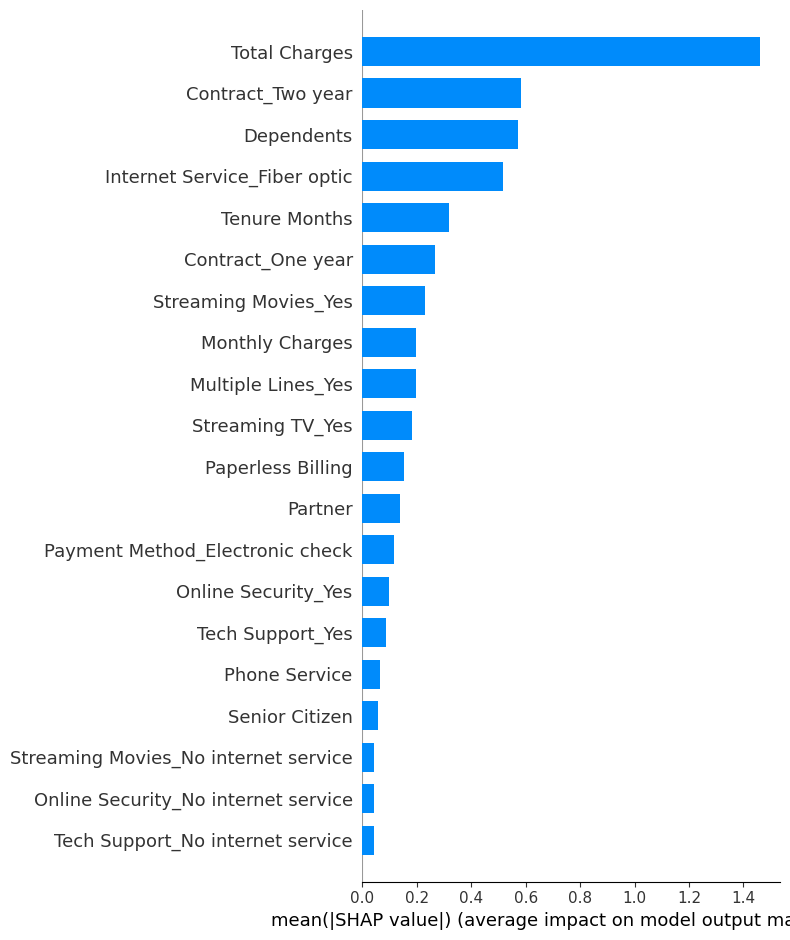

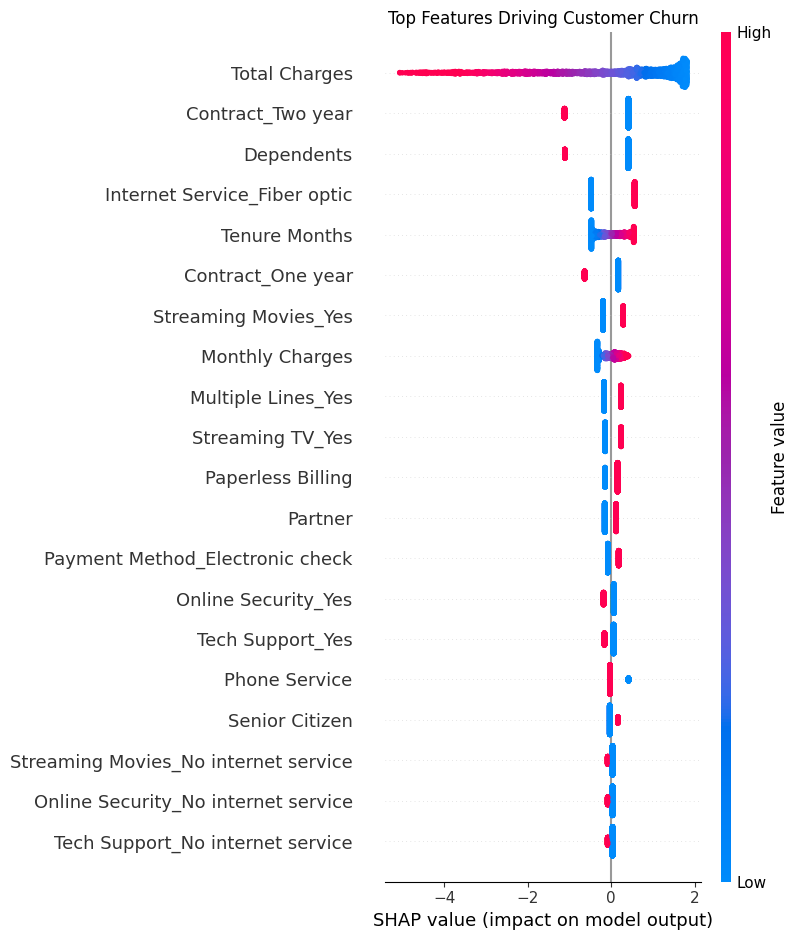

In [22]:
explainer = shap.LinearExplainer(model_lr, X_train)
shap_values = explainer.shap_values(X_test)

# For binary classification, get class 1 (churn) SHAP values
if len(shap_values.shape) == 3:
    shap_values_churn = shap_values[:, :, 1]
else:
    shap_values_churn = shap_values

# Convert back to original feature names
feature_names = X_train.columns

# MOST IMPORTANT PLOTS FOR CHURN:

# 1. Which features drive churn? (Bar plot)
shap.summary_plot(shap_values_churn, X_test, 
                  feature_names=feature_names, plot_type="bar")
plt.title("Top Features Driving Customer Churn")

# 2. How do features impact churn? (Beeswarm)
shap.summary_plot(shap_values_churn, X_test, 
                  feature_names=feature_names)


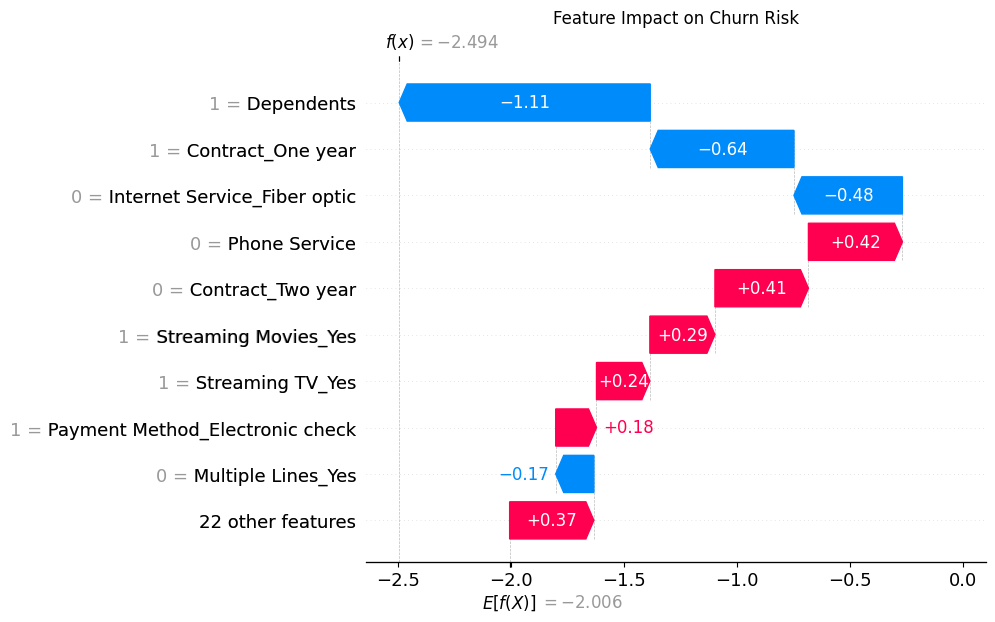

In [29]:
plt.title("Feature Impact on Churn Risk")
churn_customer_idx = 0  # Pick an actual churner
shap.plots.waterfall(shap.Explanation(
    values=shap_values_churn[churn_customer_idx],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_test.iloc[churn_customer_idx],
    feature_names=feature_names
))


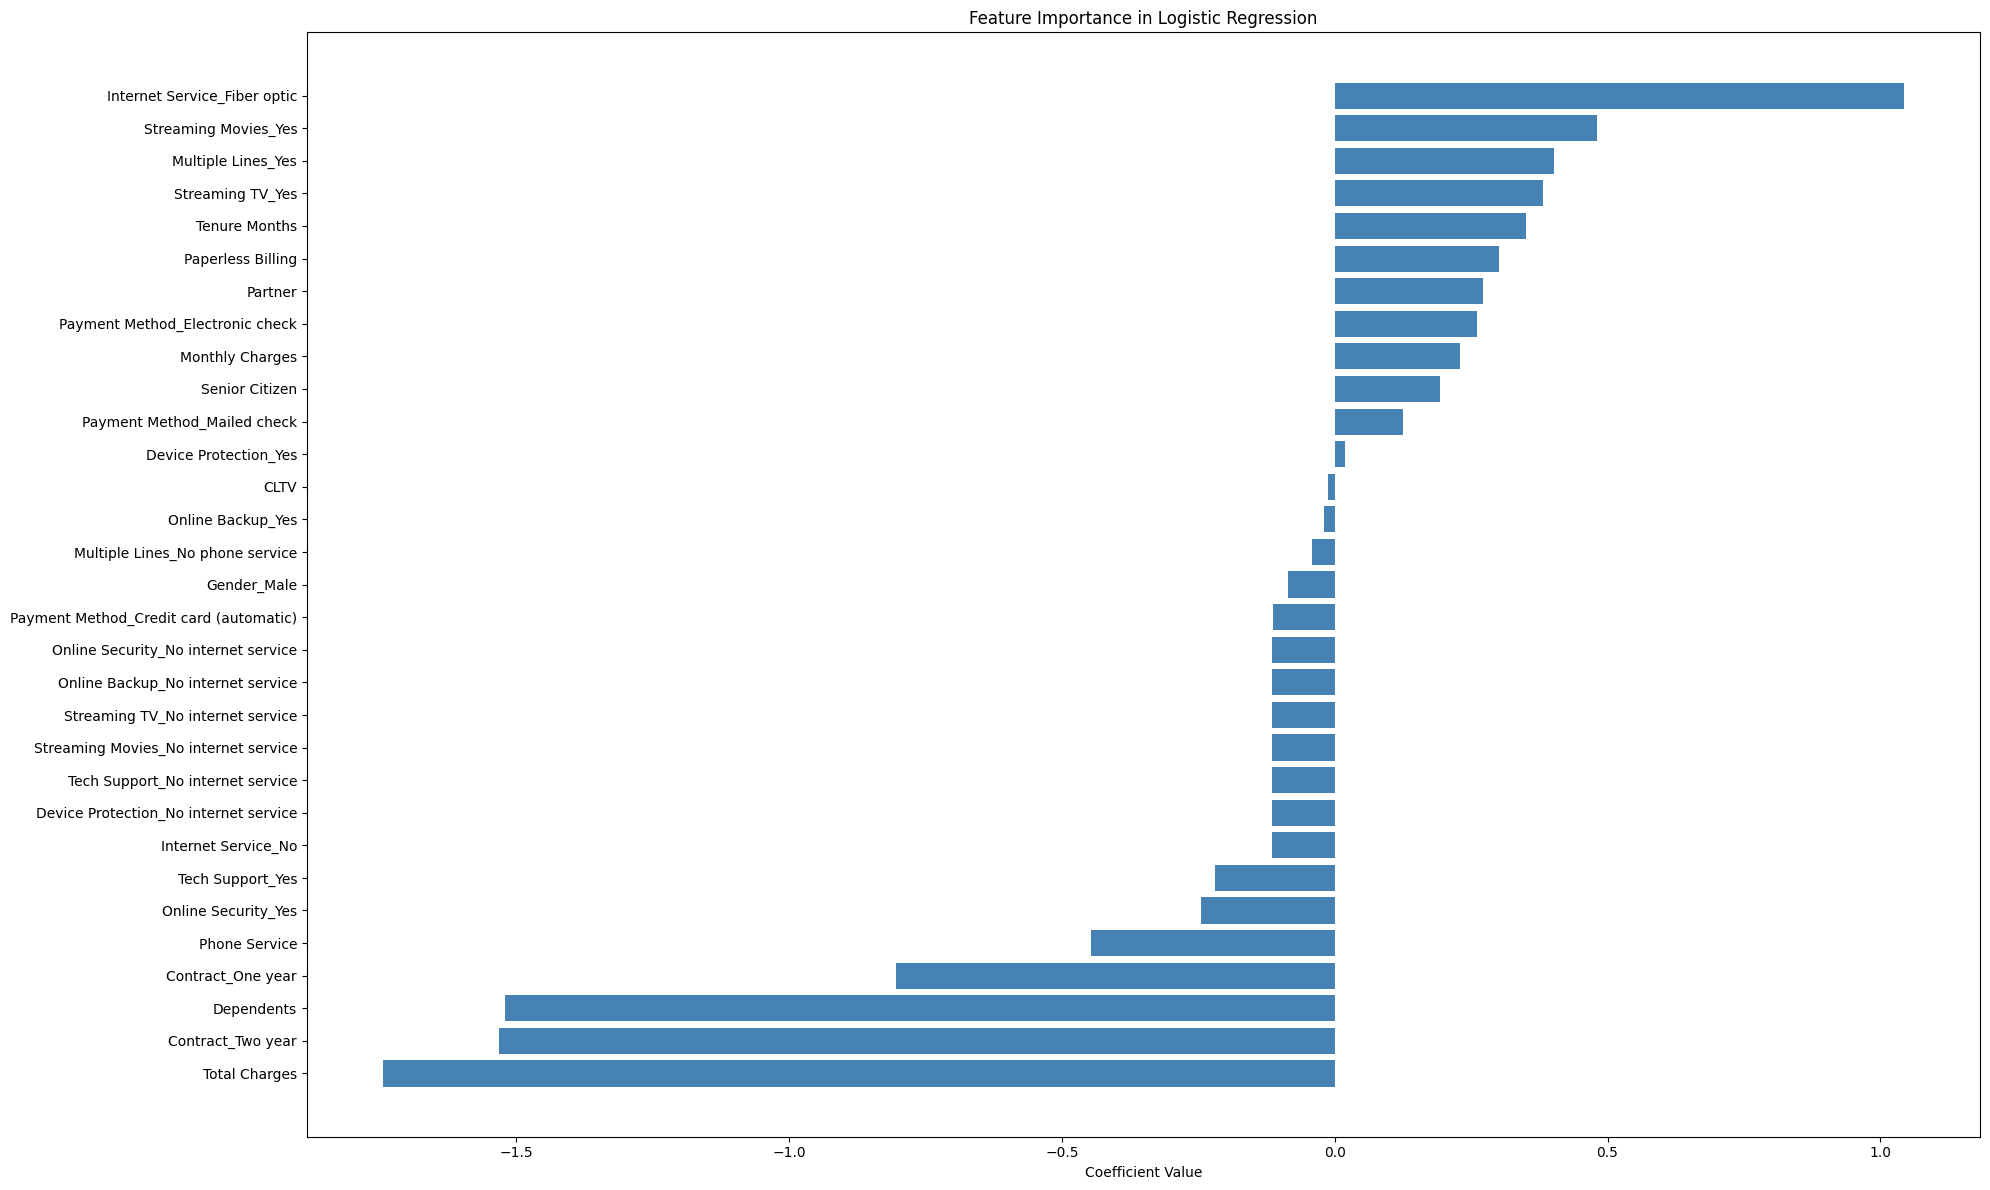

In [10]:
feature_importance = model_lr.coef_.flatten()

# Create DataFrame
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': feature_importance
})

# Sort for visualization
coef_df = coef_df.sort_values(by='Coefficient', ascending=True)

# Plot
plt.figure(figsize=(20, 12))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.tight_layout()
plt.show()

In [30]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)
y_pred=model_rf.predict(X_test)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1538
           1       0.67      0.56      0.61       575

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



In [85]:
from sklearn.metrics import accuracy_score
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    re = recall_score(y_test, y_pred, pos_label=1)

    return re


In [86]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

[I 2026-04-19 16:43:57,768] A new study created in memory with name: no-name-a5ea64c4-7272-4ad5-90d6-8ffbd746b570
[I 2026-04-19 16:43:58,019] Trial 0 finished with value: 0.5408695652173913 and parameters: {'n_estimators': 106, 'max_depth': 28, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.5408695652173913.
[I 2026-04-19 16:43:58,501] Trial 1 finished with value: 0.5339130434782609 and parameters: {'n_estimators': 161, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.5408695652173913.
[I 2026-04-19 16:43:59,200] Trial 2 finished with value: 0.5460869565217391 and parameters: {'n_estimators': 430, 'max_depth': 27, 'min_samples_split': 17, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 2 with value: 0.5460869565217391.
[I 2026-04-19 16:43:59,493] Trial 3 finished with value: 0.5547826086956522

In [87]:
model_rf = RandomForestClassifier(**study.best_params)
model_rf.fit(X_train, y_train)
y_pred=model_rf.predict(X_test)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1538
           1       0.67      0.56      0.61       575

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



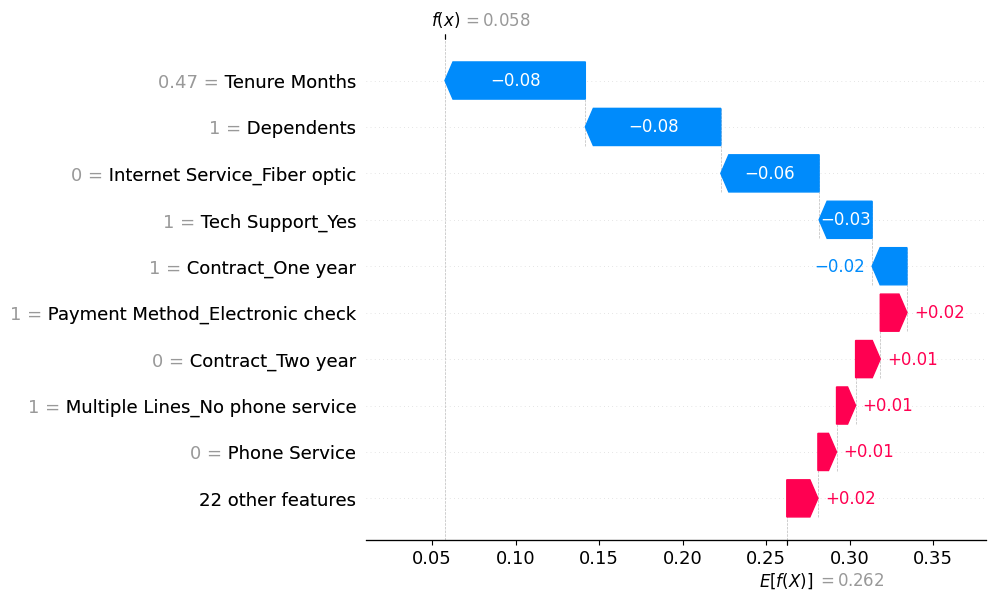

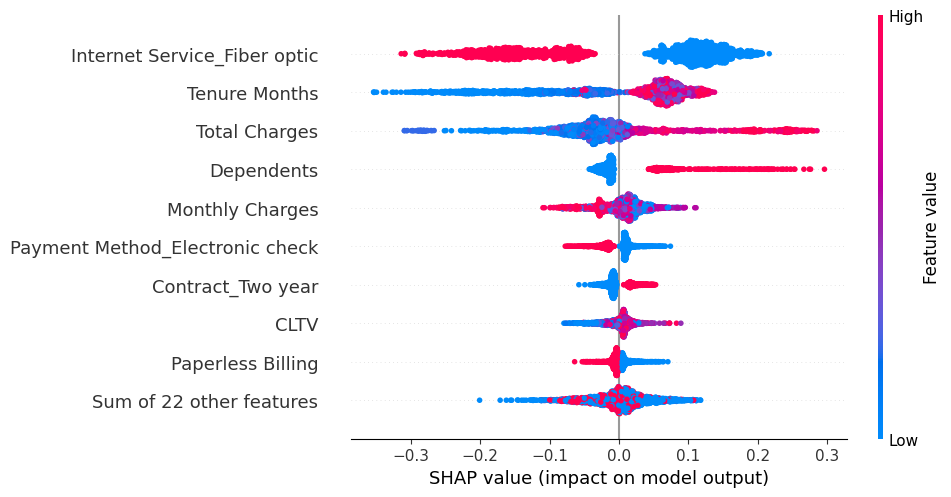

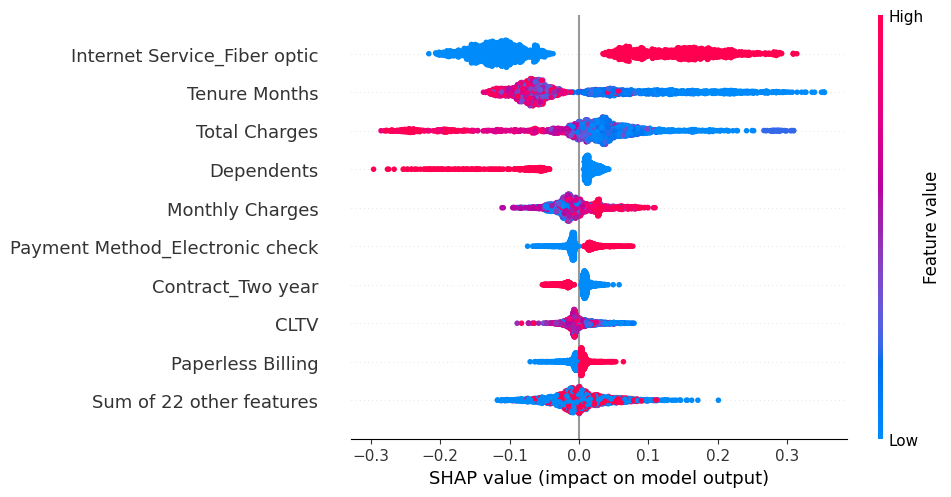

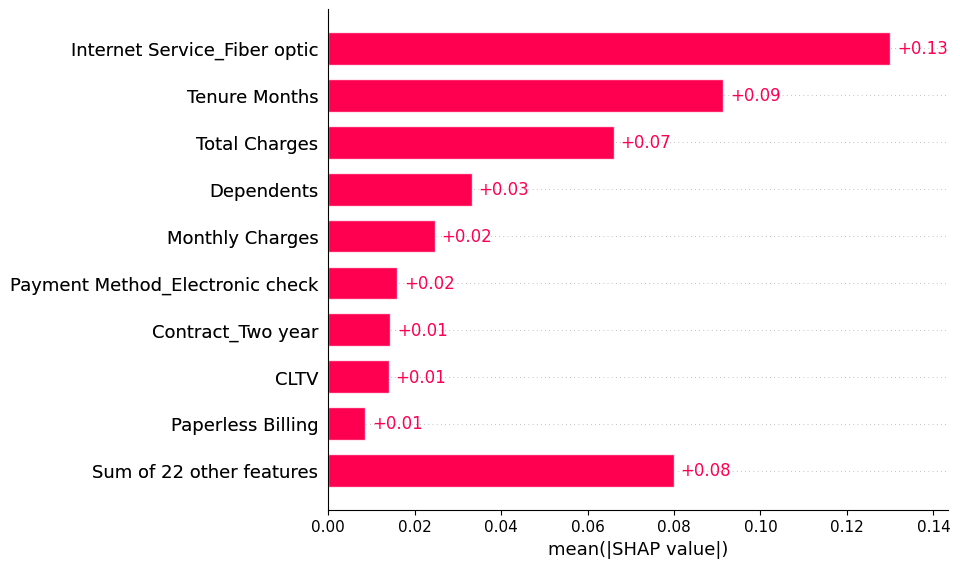

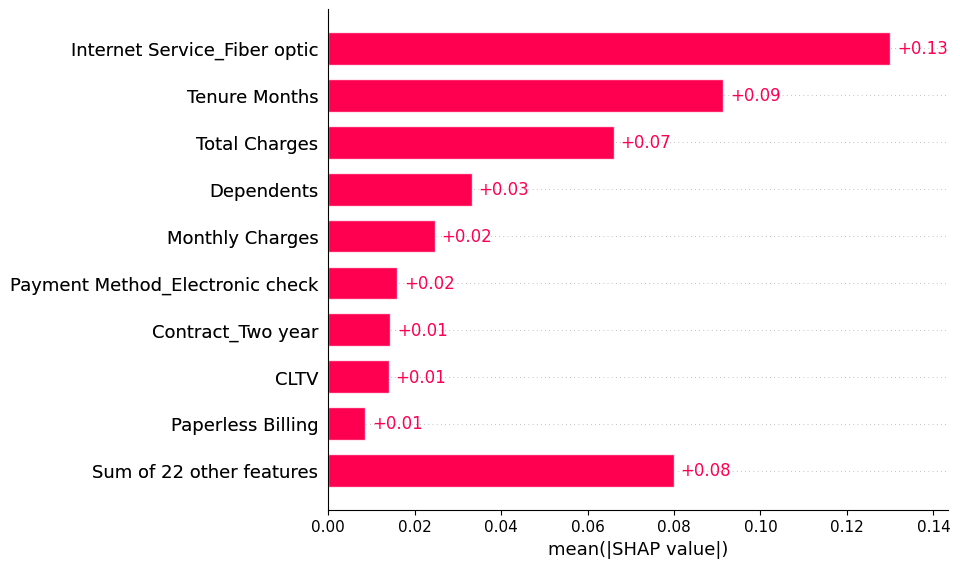

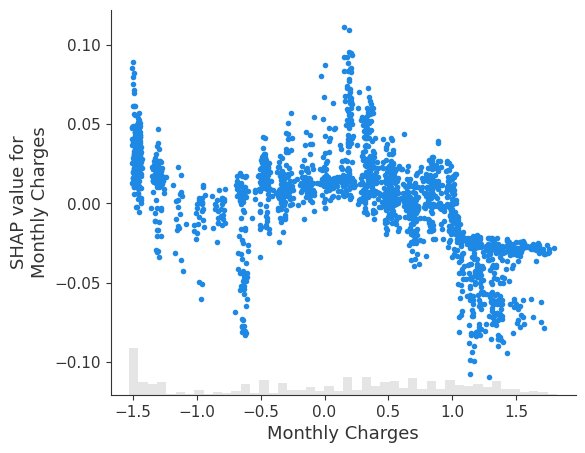

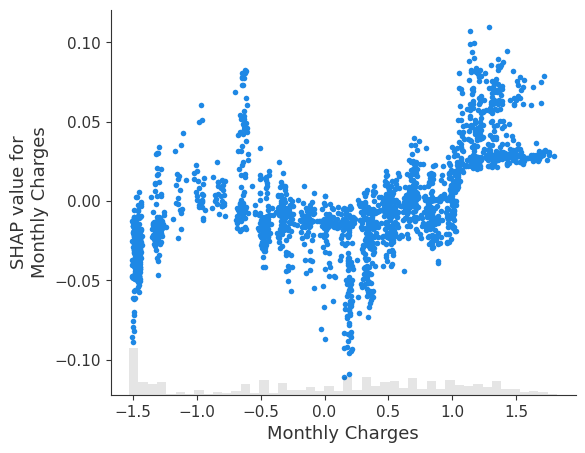

In [88]:
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer(X_test)

# --- Visualizations ---

# 1. Waterfall plot — explains a single prediction
shap.plots.waterfall(shap_values[0, :, 1])

# Beeswarm plot — select class 0 or class 1
shap.plots.beeswarm(shap_values[:, :, 0])  # class 0
shap.plots.beeswarm(shap_values[:, :, 1])  # class 1 (positive class)

# Bar plot — select class
shap.plots.bar(shap_values[:, :, 0])       # class 0
shap.plots.bar(shap_values[:, :, 1])       # class 1

# Dependence/Scatter plot — select class
feat_idx = X.columns.get_loc("Monthly Charges")
shap.plots.scatter(shap_values[:, feat_idx, 0])  # class 0
shap.plots.scatter(shap_values[:, feat_idx, 1])  # class 1

In [89]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
base_lr = DecisionTreeClassifier()

bagging_lr = BaggingClassifier(
    estimator=base_lr,
    n_estimators=50,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    random_state=42,
    n_jobs=-1
)
bagging_lr.fit(X_train, y_train)
y_pred = bagging_lr.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1538
           1       0.65      0.54      0.59       575

    accuracy                           0.80      2113
   macro avg       0.74      0.72      0.73      2113
weighted avg       0.79      0.80      0.79      2113



In [90]:
def objective(trial):

    # -------- Base Decision Tree params --------
    base_params = {
        "max_depth": trial.suggest_int("max_depth", 2, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        "random_state": 42
    }

    base_tree = DecisionTreeClassifier(**base_params)

    # -------- Bagging params --------
    bagging_params = {
        "estimator": base_tree,
        "n_estimators": trial.suggest_int("n_estimators", 20, 200),
        "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
        "max_features": trial.suggest_float("max_features", 0.5, 1.0),
        "bootstrap": True,
        "bootstrap_features": False,
        "n_jobs": -1,
        "random_state": 42
    }

    model = BaggingClassifier(**bagging_params)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = recall_score(y_test, y_pred,pos_label=1)
    return acc


In [91]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)


[I 2026-04-19 16:47:47,298] A new study created in memory with name: no-name-1283985c-0d4e-447b-bc4a-f4e295910863
[I 2026-04-19 16:47:47,756] Trial 0 finished with value: 0.5339130434782609 and parameters: {'max_depth': 19, 'min_samples_split': 18, 'min_samples_leaf': 5, 'criterion': 'gini', 'n_estimators': 190, 'max_samples': 0.8375139102900537, 'max_features': 0.5942239793137671}. Best is trial 0 with value: 0.5339130434782609.
[I 2026-04-19 16:47:48,002] Trial 1 finished with value: 0.5339130434782609 and parameters: {'max_depth': 19, 'min_samples_split': 4, 'min_samples_leaf': 8, 'criterion': 'gini', 'n_estimators': 54, 'max_samples': 0.8891706047584914, 'max_features': 0.5285833396610261}. Best is trial 0 with value: 0.5339130434782609.
[I 2026-04-19 16:47:48,261] Trial 2 finished with value: 0.5373913043478261 and parameters: {'max_depth': 10, 'min_samples_split': 12, 'min_samples_leaf': 7, 'criterion': 'gini', 'n_estimators': 63, 'max_samples': 0.5690955082360445, 'max_features'

In [92]:
print("Best Recall of Class 1:", study.best_value)
print("Best Parameters:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")


Best Recall of Class 1: 0.591304347826087
Best Parameters:
max_depth: 14
min_samples_split: 2
min_samples_leaf: 1
criterion: entropy
n_estimators: 52
max_samples: 0.9083061778214481
max_features: 0.9501571975214631


In [93]:
best_base_tree = DecisionTreeClassifier(
    max_depth=study.best_params["max_depth"],
    min_samples_split=study.best_params["min_samples_split"],
    min_samples_leaf=study.best_params["min_samples_leaf"],
    criterion=study.best_params["criterion"],
    random_state=42
)

best_bagging = BaggingClassifier(
    estimator=best_base_tree,
    n_estimators=study.best_params["n_estimators"],
    max_samples=study.best_params["max_samples"],
    max_features=study.best_params["max_features"],
    bootstrap=True,
    bootstrap_features=False,
    n_jobs=-1,
    random_state=42
)

best_bagging.fit(X_train, y_train)

y_pred = best_bagging.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1538
           1       0.66      0.59      0.62       575

    accuracy                           0.81      2113
   macro avg       0.76      0.74      0.75      2113
weighted avg       0.80      0.81      0.80      2113



In [46]:
from xgboost import XGBClassifier

In [94]:
model_xgb=XGBClassifier()
model_xgb.fit(X_train,y_train)
y_pred=model_xgb.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1538
           1       0.64      0.58      0.61       575

    accuracy                           0.80      2113
   macro avg       0.74      0.73      0.73      2113
weighted avg       0.79      0.80      0.79      2113



In [95]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "objective": "multi:softmax" if len(set(y_train)) > 2 else "binary:logistic",
        "eval_metric": "mlogloss" if len(set(y_train)) > 2 else "logloss",
        "random_state": 42,
        "n_jobs": -1,
        "tree_method": "hist"
    }

    model = XGBClassifier(**params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = recall_score(y_test, y_pred,pos_label=1)

    return acc
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

[I 2026-04-19 16:50:00,162] A new study created in memory with name: no-name-d049db50-49b3-4eb5-875c-082d11e89d05
[I 2026-04-19 16:50:00,515] Trial 0 finished with value: 0.5704347826086956 and parameters: {'n_estimators': 328, 'max_depth': 9, 'learning_rate': 0.0763700029991125, 'subsample': 0.859355443863415, 'colsample_bytree': 0.6173628229276752, 'gamma': 2.0167339290407966, 'min_child_weight': 9, 'reg_alpha': 0.5007732782219126, 'reg_lambda': 2.1206424764531606}. Best is trial 0 with value: 0.5704347826086956.
[I 2026-04-19 16:50:02,432] Trial 1 finished with value: 0.5652173913043478 and parameters: {'n_estimators': 767, 'max_depth': 9, 'learning_rate': 0.02337273318824819, 'subsample': 0.6574956499550683, 'colsample_bytree': 0.9895427750845895, 'gamma': 0.16397002470358524, 'min_child_weight': 8, 'reg_alpha': 2.022782485332696, 'reg_lambda': 0.3219952355598582}. Best is trial 0 with value: 0.5704347826086956.
[I 2026-04-19 16:50:02,763] Trial 2 finished with value: 0.57565217391

In [96]:
study.best_params

{'n_estimators': 648,
 'max_depth': 6,
 'learning_rate': 0.10540540924655442,
 'subsample': 0.7163619628638103,
 'colsample_bytree': 0.9448346108252826,
 'gamma': 3.8965454139671114,
 'min_child_weight': 8,
 'reg_alpha': 1.4866868305926688,
 'reg_lambda': 2.506425702022849}

In [97]:
model_xgb=XGBClassifier(**study.best_params)
model_xgb.fit(X_train,y_train)
y_pred=model_xgb.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1538
           1       0.67      0.57      0.62       575

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.80      2113



In [98]:
probabilities = model_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = roc_curve(y_test, probabilities)
desired_recall = 0.8
closest_index = np.argmin(abs(tpr - desired_recall))
y_pred = (probabilities >= threshold[closest_index]).astype(int)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1538
           1       0.57      0.80      0.67       575

    accuracy                           0.78      2113
   macro avg       0.74      0.79      0.75      2113
weighted avg       0.82      0.78      0.79      2113



In [99]:
probabilities = model_lr.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = roc_curve(y_test, probabilities)
desired_recall = 0.8
closest_index = np.argmin(abs(tpr - desired_recall))
y_pred = (probabilities >= threshold[closest_index]).astype(int)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1538
           1       0.56      0.80      0.66       575

    accuracy                           0.77      2113
   macro avg       0.73      0.78      0.74      2113
weighted avg       0.81      0.77      0.78      2113



In [100]:
probabilities = best_bagging.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = roc_curve(y_test, probabilities)
desired_recall = 0.8
closest_index = np.argmin(abs(tpr - desired_recall))
y_pred = (probabilities >= threshold[closest_index]).astype(int)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1538
           1       0.56      0.80      0.66       575

    accuracy                           0.77      2113
   macro avg       0.74      0.78      0.74      2113
weighted avg       0.82      0.77      0.78      2113



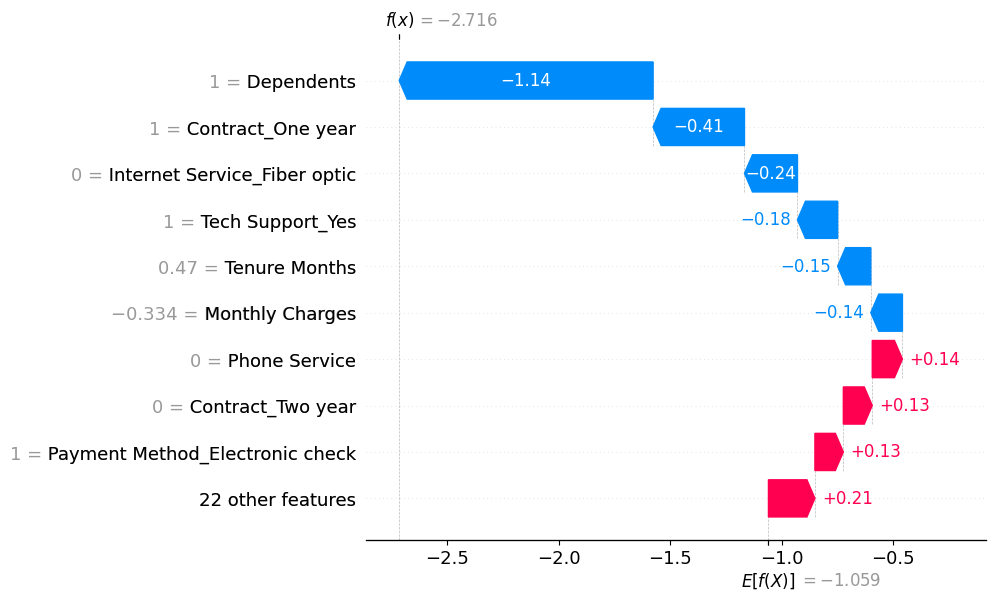

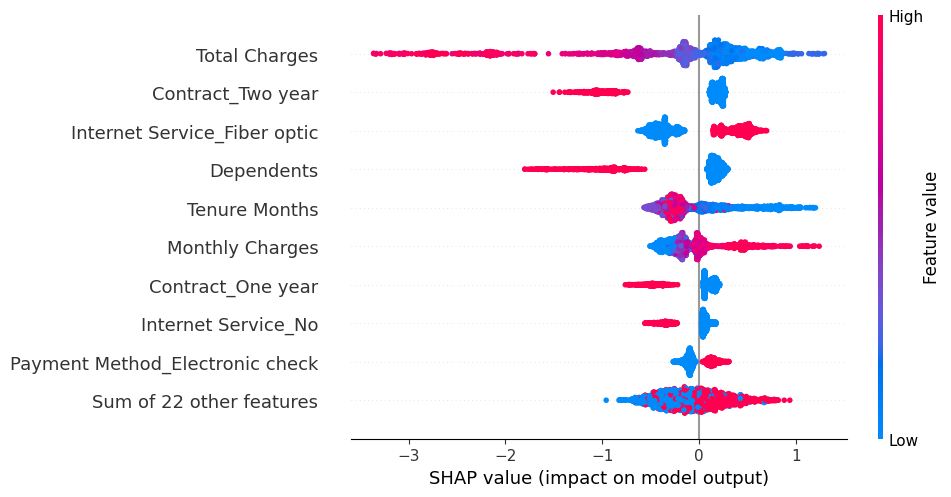

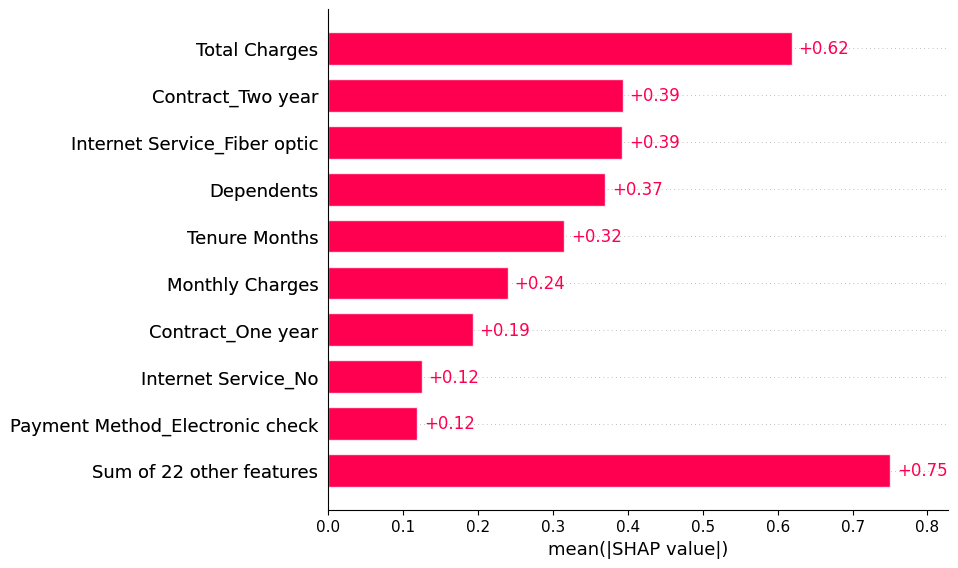

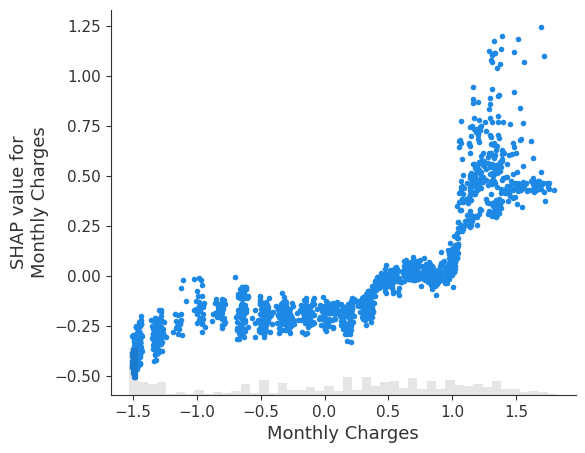

In [69]:
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_test)

# --- Visualizations ---

# 1. Waterfall plot — explains a single prediction
shap.plots.waterfall(shap_values[0])

# 2. Beeswarm plot — global feature importance
shap.plots.beeswarm(shap_values)

# 3. Bar plot — mean absolute SHAP values
shap.plots.bar(shap_values)

# 4. Dependence plot — feature interaction
shap.plots.scatter(shap_values[:, X.columns.get_loc("Monthly Charges")])  # 0 = first feature

## Model Saving

In [78]:
import joblib

In [101]:
probabilities = model_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = roc_curve(y_test, probabilities)
desired_recall = 0.8
closest_index = np.argmin(abs(tpr - desired_recall))
y_pred = (probabilities >= threshold[closest_index]).astype(int)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      1538
           1       0.57      0.80      0.67       575

    accuracy                           0.78      2113
   macro avg       0.74      0.79      0.75      2113
weighted avg       0.82      0.78      0.79      2113



In [103]:
thres=threshold[closest_index]
thres

np.float64(0.2720780670642853)

In [104]:
artifact={
    "model" : model_xgb,
    "thres" : thres
}

In [105]:
joblib.dump(artifact,"../artifacts/Model_with_Threshold.pkl")

['../artifacts/Model_with_Threshold.pkl']